# Hava Kalitesi Verisi: Keşifçi Veri Analizi ve İstatistiksel Anomali Tespiti
Bu çalışma, sensörlerden elde edilen hava kalitesi verilerindeki hatalı ölçümleri temizlemeyi, veriyi görselleştirmeyi ve klasik istatistiksel yöntemler (Z-Skoru, Q-Q Plot) ile anomali (aykırı değer) tespit etmeyi amaçlamaktadır.

### 1. Veri Yükleme ve Ön İşleme
Öncelikle veriyi yüklüyor, cihazın kapalı olduğu anları belirten `-200` değerlerini boşluk (`NaN`) ile değiştiriyor ve %90'ı boş olan `NMHC(GT)` sütununu veri setinden çıkarıyoruz.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

import warnings
warnings.filterwarnings('ignore') # Gereksiz uyarıları gizlemek için

# Veriyi oku (Dosya adını kendi CSV dosyana göre güncelle)
data = pd.read_csv('AirQualityUCI.csv', sep=';', decimal=',')

# En sondaki gereksiz boş sütunları ve satırları temizle
data = data.dropna(how='all', axis=1) 
data = data.dropna(how='all', axis=0)

# Cihaz hata kodu olan -200'leri NaN yap
data = data.replace(-200, np.nan)

# Çok fazla eksik veri içeren NMHC(GT) sütununu sil
data = data.drop(columns=['NMHC(GT)'])

# Modelleme ve analiz için sadece sayısal verileri tut ve eksik satırları sil
data_temiz = data.drop(columns=['Date', 'Time']).dropna()

print(f"Temizlenmiş veri boyutu: {data_temiz.shape}")
data_temiz.head()

Temizlenmiş veri boyutu: (6941, 12)


,CO(GT),PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,2.6,1360.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
1,2.0,1292.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2,2.2,1402.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
3,2.2,1376.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
4,1.6,1272.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888


### 2. Veri Görselleştirme (EDA)
Grafiklerle verinin dağılımına ve değişkenler arası ilişkilere göz atalım.

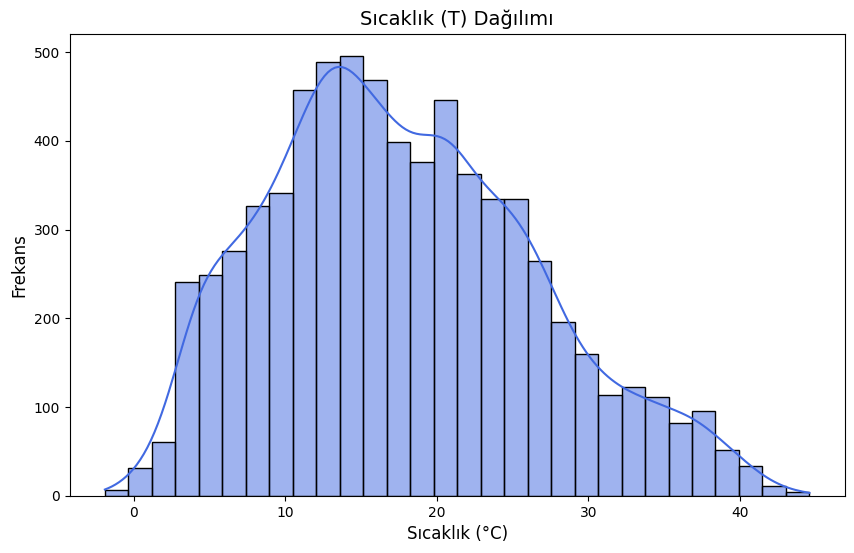

In [2]:
# 1. GRAFİK: Sıcaklık Dağılımı (Histogram)
plt.figure(figsize=(10, 6))
sns.histplot(data_temiz['T'], kde=True, bins=30, color='royalblue') 
plt.title('Sıcaklık (T) Dağılımı', fontsize=14)
plt.xlabel('Sıcaklık (°C)', fontsize=12)
plt.ylabel('Frekans', fontsize=12)
plt.show()

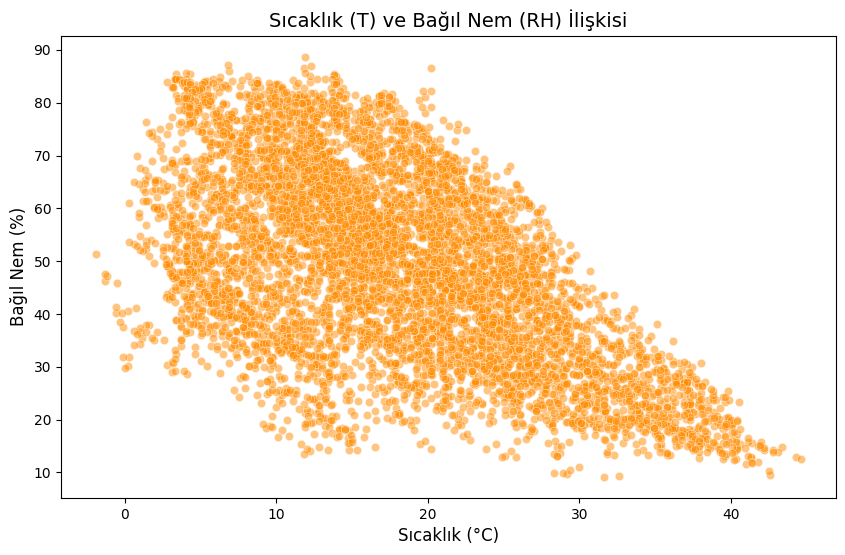

In [3]:
# 2. GRAFİK: Sıcaklık ve Nem İlişkisi (Scatter Plot)
plt.figure(figsize=(10, 6))
sns.scatterplot(x='T', y='RH', data=data_temiz, alpha=0.5, color='darkorange')
plt.title('Sıcaklık (T) ve Bağıl Nem (RH) İlişkisi', fontsize=14)
plt.xlabel('Sıcaklık (°C)', fontsize=12)
plt.ylabel('Bağıl Nem (%)', fontsize=12)
plt.show()

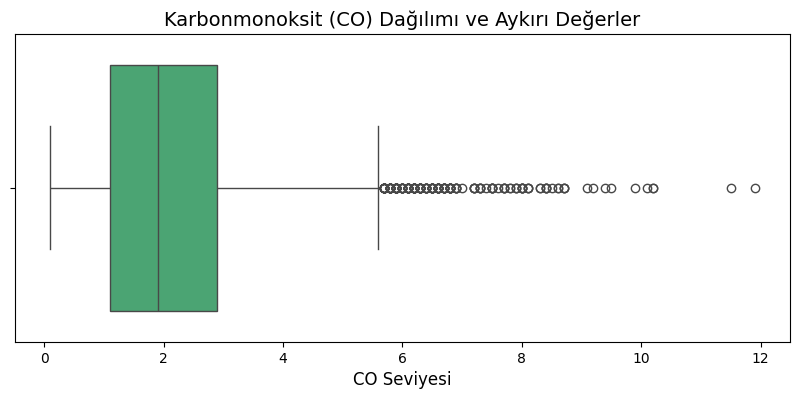

In [4]:
# 3. GRAFİK: Karbonmonoksit Aykırı Değerleri (Boxplot)
plt.figure(figsize=(10, 4))
sns.boxplot(x=data_temiz['CO(GT)'], color='mediumseagreen')
plt.title('Karbonmonoksit (CO) Dağılımı ve Aykırı Değerler', fontsize=14)
plt.xlabel('CO Seviyesi', fontsize=12)
plt.show()

### 3. İstatistiksel Anomali Tespiti (Sıcaklık Sütunu Üzerinden)
Normal dağılım parametrelerini, Z-skorlarını ve güven aralıklarını hesaplıyoruz. Q-Q plot çizimi ile normallik testini gerçekleştiriyoruz.

In [5]:
# Analiz edilecek sütun
secilen_kolon = 'T'
veri = data_temiz[secilen_kolon]

# 1. PARAMETRE TAHMİNİ
mu = veri.mean()
sigma = veri.std()

print("--- 1. PARAMETRE TAHMİNİ ---")
print(f"Ortalama (μ): {mu:.4f}")
print(f"Standart Sapma (σ): {sigma:.4f}\n")

# 2. Z-SKORU HESAPLAMA
data_temiz['Z_Skoru'] = (veri - mu) / sigma

# 3. 68-95-99.7 KURALI
oran_1 = len(veri[(data_temiz['Z_Skoru'] >= -1) & (data_temiz['Z_Skoru'] <= 1)]) / len(veri) * 100
oran_2 = len(veri[(data_temiz['Z_Skoru'] >= -2) & (data_temiz['Z_Skoru'] <= 2)]) / len(veri) * 100
oran_3 = len(veri[(data_temiz['Z_Skoru'] >= -3) & (data_temiz['Z_Skoru'] <= 3)]) / len(veri) * 100

print("--- 3. 68-95-99.7 KURALI KONTROLÜ ---")
print(f"±1 Std Sapma (Beklenen ~%68): %{oran_1:.2f}")
print(f"±2 Std Sapma (Beklenen ~%95): %{oran_2:.2f}")
print(f"±3 Std Sapma (Beklenen ~%99.7): %{oran_3:.2f}\n")

--- 1. PARAMETRE TAHMİNİ ---
Ortalama (μ): 17.7553
Standart Sapma (σ): 8.8449

--- 3. 68-95-99.7 KURALI KONTROLÜ ---
±1 Std Sapma (Beklenen ~%68): %66.47
±2 Std Sapma (Beklenen ~%95): %95.95
±3 Std Sapma (Beklenen ~%99.7): %99.97



--- 4. NORMALLİK TESTİ (SHAPIRO-WILK) ---
Test İstatistiği: 0.9816, p-değeri: 4.8761e-29
Sonuç: Veri normal dağılıma uymuyor (P-değeri < 0.05).


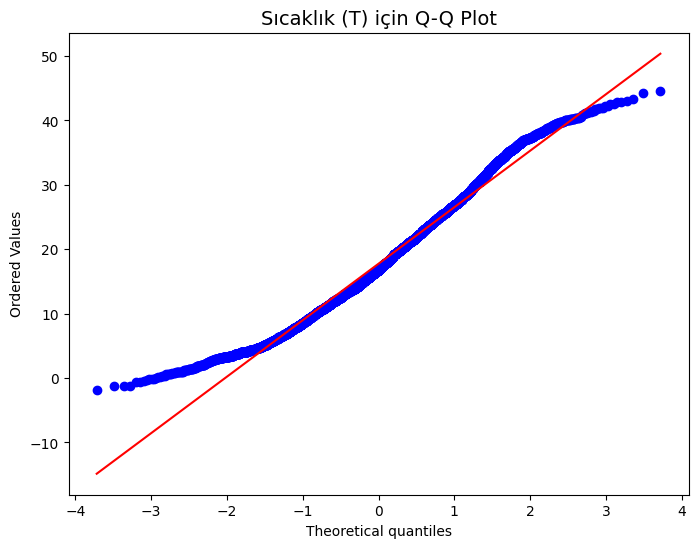

In [6]:
# 4. NORMALLİK TESTLERİ
print("--- 4. NORMALLİK TESTİ (SHAPIRO-WILK) ---")
stat, p_value = stats.shapiro(veri)
print(f"Test İstatistiği: {stat:.4f}, p-değeri: {p_value:.4e}")
if p_value > 0.05:
    print("Sonuç: Veri normal dağılıma uyuyor.")
else:
    print("Sonuç: Veri normal dağılıma uymuyor (P-değeri < 0.05).")

# Q-Q Plot Çizimi (Ayrı Grafik)
plt.figure(figsize=(8, 6))
stats.probplot(veri, dist="norm", plot=plt)
plt.title(f"Sıcaklık (T) için Q-Q Plot", fontsize=14)
plt.show()

In [7]:
# 5. ANOMALİ TESPİTİ (|Z| > 3)
anomaliler = data_temiz[abs(data_temiz['Z_Skoru']) > 3]

print("--- 5. ANOMALİ TESPİTİ ---")
print(f"Toplam tespit edilen anomali sayısı: {len(anomaliler)}")
if len(anomaliler) > 0:
    print("\nÖrnek Aykırı Değerler (Anomaliler):")
    display(anomaliler[[secilen_kolon, 'Z_Skoru']].head(10)) # Jupyter'de tabloyu güzel göstermek için display kullanılır

# 6. GÜVEN ARALIKLARI (%95)
n = len(veri)
standart_hata = sigma / np.sqrt(n)
alt_sinir, ust_sinir = stats.norm.interval(0.95, loc=mu, scale=standart_hata)

print("\n--- 6. GÜVEN ARALIKLARI ---")
print(f"Popülasyon Ortalaması için %95 Güven Aralığı: ({alt_sinir:.4f},  {ust_sinir:.4f})")

--- 5. ANOMALİ TESPİTİ ---
Toplam tespit edilen anomali sayısı: 2

Örnek Aykırı Değerler (Anomaliler):


,T,Z_Skoru
3213,44.3,3.001125
3214,44.6,3.035043



--- 6. GÜVEN ARALIKLARI ---
Popülasyon Ortalaması için %95 Güven Aralığı: (17.5472,  17.9634)
